In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2️⃣ Load dataset
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# 3️⃣ Preprocessing
data['Genre'] = data['Genre'].astype(str).str.strip().str.capitalize()
data['Genre'] = data['Genre'].map({'Male': 1, 'Female': 0})
print(data.isnull().sum())  # Check for missing values



CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
data['Genre']

,Genre
0,1
1,1
2,0
3,0
4,0
...,...
195,0
196,0
197,1
198,1


In [7]:
# 4️⃣ Feature selection
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [6]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [10]:
# 5️⃣ KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
data['KMeans_Cluster'] = labels_kmeans
data


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4
...,...,...,...,...,...,...
195,196,0,35,120,79,1
196,197,0,45,126,28,3
197,198,1,32,126,74,1
198,199,1,32,137,18,3


In [11]:
# 6️⃣ Agglomerative clustering
agglo = AgglomerativeClustering(n_clusters=5)
labels_agglo = agglo.fit_predict(X_scaled)
data['Agglo_Cluster'] = labels_agglo
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Agglo_Cluster
0,1,1,19,15,39,4,4
1,2,1,21,15,81,2,3
2,3,0,20,16,6,4,4
3,4,0,23,16,77,2,3
4,5,0,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,0,35,120,79,1,1
196,197,0,45,126,28,3,0
197,198,1,32,126,74,1,1
198,199,1,32,137,18,3,0


Text(0, 0.5, 'Spending Score (scaled)')

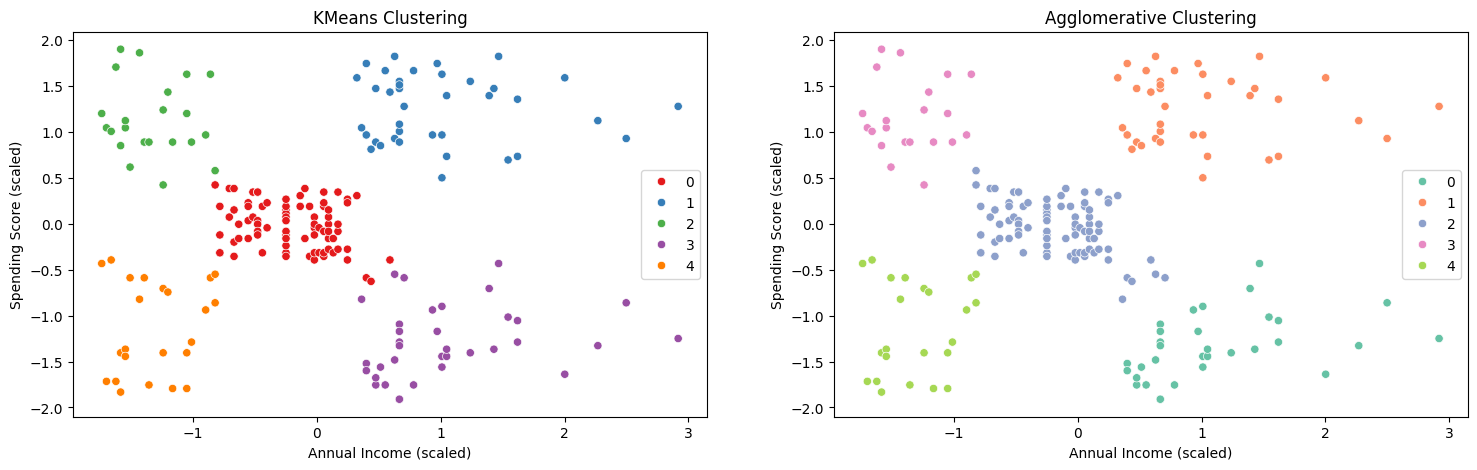

In [13]:
# 8️⃣ Visualization
plt.figure(figsize=(18,5))

# KMeans
plt.subplot(1,2,1)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels_kmeans, palette='Set1')
plt.title("KMeans Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

# Agglomerative
plt.subplot(1,2,2)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels_agglo, palette='Set2')
plt.title("Agglomerative Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")